# Trajectory Analysis across models for Suo et. al.

In [1]:
0

0

In [2]:
import sys

working_directory = "/home/icb/kemal.inecik/work/codes/sctram"
sys.path.append(working_directory)
sys.path.append("/home/icb/kemal.inecik/work/codes/sctram/reproducibility/server_sync/experiments")

import gc
import itertools
import logging
import os
import subprocess
import time

import numpy as np
import pandas as pd

In [3]:
from helper.plot_obsms import plot_obsms
from incremental_training.helper.constants import (
    metric_direction_dict,
    trajectory_classification_dict,
)
from sctram.api._lower_level import TrajectoryEvaluationAPI
from sctram.generate.real import sc_suo_developmental_complete
from sctram.input import InputTrajectories

2025-06-04 08:44:10.827 | INFO     | sctram.api._defaults_read:load_default_metrics:23 - Loaded default metrics from /home/icb/kemal.inecik/work/codes/sctram/sctram/api/_defaults.yaml
2025-06-04 08:44:10.828 | INFO     | sctram.api._defaults_read:load_default_metrics:79 - Default metrics YAML structure validated successfully.


In [199]:
# Important to have consistent figures across platforms

%matplotlib inline
%config InlineBackend.figure_format='retina'

import pickle

import colorcet as cc
import matplotlib as mpl
import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import plottable
import seaborn as sns
from adjustText import adjust_text
from matplotlib import gridspec
from matplotlib.ticker import FormatStrFormatter
from networkx.drawing.nx_agraph import graphviz_layout

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pandas as pd
from plottable import ColumnDefinition, Table
from plottable.cmap import normed_cmap
from plottable.plots import bar

_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, "rb") as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

In [5]:
dataset_dir = "/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data"
helpers_directory = os.path.join(os.getcwd(), "helper")
logs_directory = os.path.join(os.getcwd(), "logs")

## scTRAM Data

In [6]:
adata_suo_complete = sc_suo_developmental_complete(dataset_dir=dataset_dir)

n_neighbors = 50
lineages = ["Haematopoeitic_lineage"]

2025-06-04 08:44:15.435 | WARNING  | sctram.generate.real._download:download_dataset:105 - File PosixPath('/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/suo_developmental_complete.h5ad') already exists. Skipping download.


In [7]:
input_trajectories_path = os.path.join(dataset_dir, f"adata_suo_input_haematopoeitic_lineage.pkl")
with open(input_trajectories_path, "rb") as _file:
    lit = pickle.load(_file)

In [8]:
df = pd.DataFrame()
lineage = "Haematopoeitic_lineage"
for trajectory in sorted(lit.graph["trajectories"]):
    lineage_part = lineage.replace("_lineage", "").lower()
    for use_rep in adata_suo_complete.obsm.keys():
        if use_rep == "Unintegrated":
            continue
        output_file = os.path.join(dataset_dir, f"_metric_adata_suo_{lineage_part}_{use_rep}_{trajectory}.pickle")
        df_trajectory_obsm = pd.read_pickle(output_file)
        df_trajectory_obsm["representation"] = use_rep
        df_trajectory_obsm["trajectory"] = trajectory
        df = pd.concat([df, df_trajectory_obsm])
df.reset_index(drop=True, inplace=True)
df["score"] = pd.to_numeric(df["score"], errors="raise")
df.sort_values(by=["trajectory", "path", "metric", "representation"], inplace=True, ignore_index=True)
df = df[["trajectory", "path", "metric", "representation", "score"]]
df["trajectory_class"] = [trajectory_classification_dict[r["trajectory"]] for _, r in df.iterrows()]

In [9]:
def rank_metrics(df, metric_direction_dict, metric_index_pos, method="min"):
    ranked_df = pd.DataFrame(index=df.index, columns=df.columns, dtype=float)
    for indices, row in df.iterrows():

        metric = indices[metric_index_pos]
        direction = metric_direction_dict.get(metric)

        if direction not in ("increasing", "decreasing"):
            raise ValueError

        numeric_row = pd.to_numeric(row, errors="coerce")
        if numeric_row.isna().any():
            ranked_df.loc[indices] = np.nan
            continue

        if direction == "increasing":
            ranks = numeric_row.rank(method="dense", ascending=False)
        else:
            ranks = numeric_row.rank(method="dense", ascending=True)

        # ranks = 1 - pd.Series(MinMaxScaler().fit_transform(row.values.reshape(-1, 1)).flatten(), index=row.index)

        ranked_df.loc[indices] = ranks.astype("Float64")
    return ranked_df

In [10]:
df_pivot = df.pivot(
    index=["trajectory_class", "trajectory", "path", "metric"], columns="representation", values="score"
)
df_pivot_rank = rank_metrics(df_pivot, metric_direction_dict, metric_index_pos=3, method="min")

## scIB Data

In [11]:
df_scib_a = pd.concat(
    [
        pd.read_pickle(
            "/lustre/groups/ml01/workspace/kemal.inecik/tardis_data/_temporary/latent/suo_scvi_30_latent_scib_bioconservation.pickle"
        ),
        pd.read_pickle(
            "/lustre/groups/ml01/workspace/kemal.inecik/tardis_data/_temporary/latent/suo_scvi_15_latent_scib_batchcorrection.pickle"
        ),
    ],
    axis=1,
).T
for l in ["01_01", "01_02", "01_03", "01_04", "01_05", "02_01", "02_02", "02_03", "02_04"]:
    df_scib_b = pd.concat(
        [
            pd.read_pickle(
                f"/lustre/groups/ml01/workspace/kemal.inecik/tardis_data/_temporary/latent/suo_v{l}_2_tardis_30_latent_scib_bioconservation.pickle"
            ),
            pd.read_pickle(
                f"/lustre/groups/ml01/workspace/kemal.inecik/tardis_data/_temporary/latent/suo_v{l}_2_tardis_15_latent_scib_batchcorrection.pickle"
            ),
        ],
        axis=1,
    ).T
    df_scib_a[f"tardis_{l}"] = df_scib_b.loc[df_scib_a.index, "tardis"]
df_scib_b = pd.concat(
    [
        pd.read_pickle(
            os.path.join(
                "/lustre/groups/ml01/workspace/kemal.inecik/tardis_data/_temporary",
                "latent",
                "suo_scib_scanvi_bio_2.pickle",
            )
        ),
        pd.read_pickle(
            os.path.join(
                "/lustre/groups/ml01/workspace/kemal.inecik/tardis_data/_temporary",
                "latent",
                "suo_scib_scanvi_batch_2.pickle",
            )
        ),
    ],
    axis=1,
).T
df_scib_a[f"scanvi"] = df_scib_b.loc[df_scib_a.index, "scanvi"]
df_scib_c = pd.concat(
    [
        pd.read_pickle(
            os.path.join(
                "/lustre/groups/ml01/workspace/kemal.inecik/tardis_data/_temporary",
                "latent",
                "suo_scib_invae_bio.pickle",
            )
        ),
        pd.read_pickle(
            os.path.join(
                "/lustre/groups/ml01/workspace/kemal.inecik/tardis_data/_temporary",
                "latent",
                "suo_scib_invae_batch.pickle",
            )
        ),
    ],
    axis=1,
).T
invae_models = [i for i in df_scib_c.columns if i.startswith("inveriant")]
df_scib_c = df_scib_c.loc[df_scib_a.index, invae_models]
df_scib_c.columns = ["invae_" + i.split("inveriant_")[1] for i in df_scib_c.columns]
df_scib_a = pd.concat([df_scib_a, df_scib_c], axis=1)
total_score = []
for c in df_scib_a.columns:
    if c != "Metric Type":
        item = 0.4 * df_scib_a[c].loc["Batch correction"] + 0.6 * df_scib_a[c].loc["Bio conservation"]
    else:
        item = "Aggregate score"
    total_score.append(item)
df_scib_a = df_scib_a.T
df_scib_a["Total scIB"] = total_score
df_scib_a = df_scib_a.T
df_scib = df_scib_a.sort_values(by=["Metric Type"], ascending=False)

df_scib = df_scib[["X_pca", "harmony", "scvi", "scanvi", "invae_7", "tardis_01_01", "tardis_02_02"]]
df_scib.rename(columns={"invae_7": "invae", "tardis_01_01": "tardis_1", "tardis_02_02": "tardis_2"}, inplace=True)

df_scib.index.name = "metric"
df_scib.columns.name = "representation"

In [12]:
rename_model_name_dict = {
    "X_pca": "PCA",
    "harmony": "Harmony",
    "invae": "inVAE",
    "scanvi": "scANVI",
    "scvi": "scVI",
    "tardis_1": "DELETE ME",
    "tardis_2": "TarDis",
}
col_order = ["PCA", "Harmony", "inVAE", "TarDis", "scANVI", "scVI"]

In [13]:
sctram_summary = 1 / df_pivot_rank.groupby(level=[2, 3]).mean().groupby(level=0).mean()
_sctram_summary = 1 / pd.DataFrame(df_pivot_rank.groupby(level=3).mean().mean(), columns=["Total scTRAM"]).T
sctram_summary = pd.concat([sctram_summary, _sctram_summary], axis=0)
sctram_summary = sctram_summary.rename(
    index={"adjacency": "Adjacency-based", "embedding": "Embedding-based", "pseudotime": "Pseudotime-based"},
    columns=rename_model_name_dict,
)[col_order]
sctram_summary.index.name = None
sctram_summary.columns.name = "Representation"
sctram_summary

Representation,PCA,Harmony,inVAE,TarDis,scANVI,scVI
Adjacency-based,0.324852,0.253351,0.345770,0.336181,0.332693,0.285270
Embedding-based,0.278607,0.221885,0.267766,0.260464,0.356701,0.234225
Pseudotime-based,0.277635,0.200093,0.223140,0.296500,0.316252,0.219289
Total scTRAM,0.296742,0.225960,0.276628,0.302531,0.332061,0.248010


In [14]:
scib_summary = df_scib.loc[["Bio conservation", "Batch correction", "Total scIB"]]
scib_summary = scib_summary.rename(columns=rename_model_name_dict)[col_order]
scib_summary.index.name = None
scib_summary.columns.name = "Representation"
scib_summary

Representation,PCA,Harmony,inVAE,TarDis,scANVI,scVI
Bio conservation,0.605958,0.568814,0.629309,0.643031,0.700526,0.598137
Batch correction,0.401851,0.491666,0.38215,0.626922,0.522836,0.603161
Total scIB,0.524315,0.537955,0.530446,0.636587,0.62945,0.600147


In [208]:
summary = pd.concat([scib_summary, sctram_summary], keys=["scIB", "scTRAM"], axis=0)
summary.index.names = ["Source", "Metric Group"]
summary.columns.name = "Representation"
new_index_tuples = [
    ("Aggregate score", metric.split("Total ")[1]) if metric.startswith("Total ") else (src, metric) for src, metric in summary.index
]
summary.index = pd.MultiIndex.from_tuples(new_index_tuples, names=summary.index.names)

weights = {  # just provisional for now
    "scTRAM": 0.4,
    "scIB": 0.6,
}
row_ts = summary.loc[("Aggregate score", "scTRAM")]
row_si = summary.loc[("Aggregate score", "scIB")]
combined = weights["scTRAM"] * row_ts + weights["scIB"] * row_si
combined_df = pd.DataFrame(combined).T
combined_df.index = pd.MultiIndex.from_tuples([("Aggregate score", "Total")], names=summary.index.names)
summary = pd.concat([summary, combined_df])

summary = summary.sort_index(ascending=False)
summary = summary.sort_values(by=[("Aggregate score", "Total")], axis=1, ascending=True).astype(np.float64)

summary_T = summary.T
summary

Representation                     Harmony     inVAE       PCA      scVI  \
Source          Metric Group                                               
scTRAM          Pseudotime-based  0.200093  0.223140  0.277635  0.219289   
                Embedding-based   0.221885  0.267766  0.278607  0.234225   
                Adjacency-based   0.253351  0.345770  0.324852  0.285270   
scIB            Bio conservation  0.568814  0.629309  0.605958  0.598137   
                Batch correction  0.491666  0.382150  0.401851  0.603161   
Aggregate score scTRAM            0.225960  0.276628  0.296742  0.248010   
                scIB              0.537955  0.530446  0.524315  0.600147   
                Total             0.413157  0.428919  0.433286  0.459292   

Representation                      TarDis    scANVI  
Source          Metric Group                          
scTRAM          Pseudotime-based  0.296500  0.316252  
                Embedding-based   0.260464  0.356701  
                Adjacency-based   0.336181  0.332693  
scIB            Bio conservation  0.643031  0.700526  
                Batch correction  0.626922  0.522836  
Aggregate score scTRAM            0.302531  0.332061  
                scIB              0.636587  0.629450  
                Total             0.502965  0.510494

# Plotting

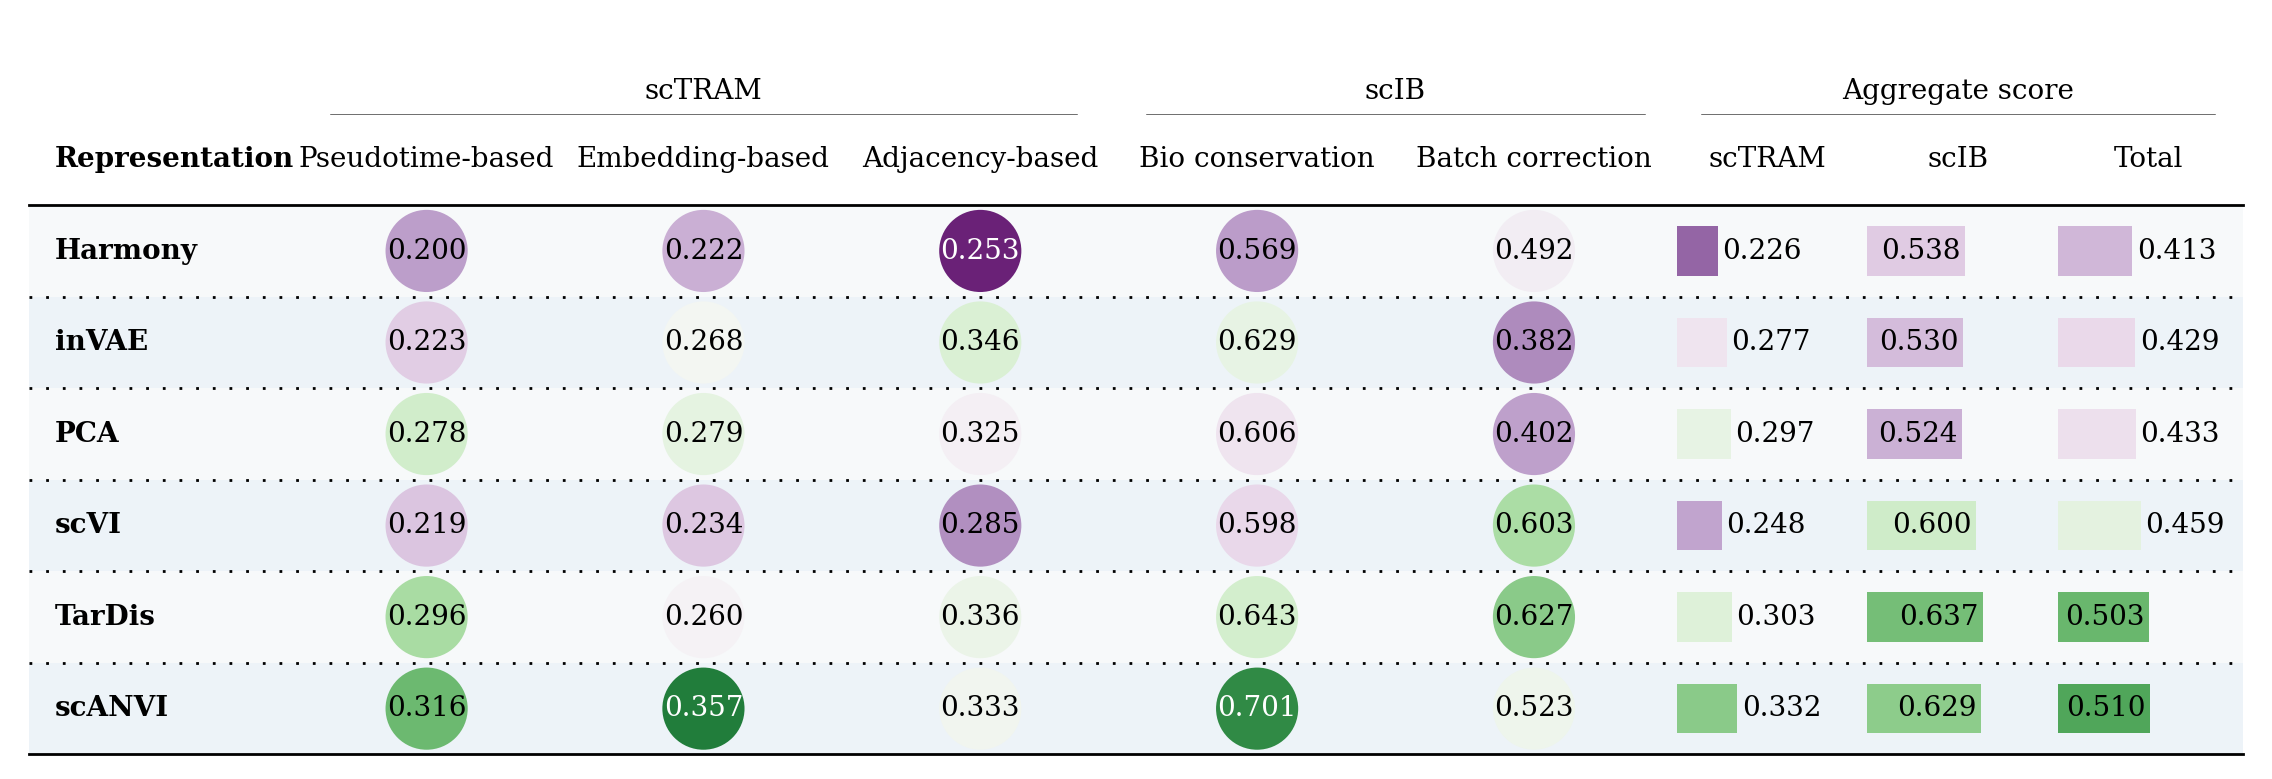

In [239]:
df_plot = summary_T.reset_index().copy()
df_plot_dict = {f"{lvl0}\n{lvl1}": (lvl0, lvl1) for (lvl0, lvl1) in df_plot.columns}
df_plot.columns = [f"{lvl0}\n{lvl1}" for (lvl0, lvl1) in df_plot.columns]

cmap_fn = lambda col_data: normed_cmap(col_data, cmap=cm.PRGn, num_stds=2.5)

col_defs = []
for col in df_plot.columns:
    # Create a “normalized color map” for this column:
    lvl0, lvl1 = df_plot_dict[col]
    if lvl0 == "Aggregate score" or lvl0 == "Representation":
        continue
    cmap = cmap_fn(df_plot[col])

    cd = ColumnDefinition(
        name=col,  # Must exactly match the flattened column name in df_plot
        width=0.8,  # width of each column in inches (tweak as needed)
        cmap=cmap,  # cell background colormap (normed by this column’s values)
        text_cmap=cmap,  # text color also follows same colormap
        textprops={
            "ha": "center",
            "bbox": {"boxstyle": "circle", "pad": 0},
        },
        group=lvl0,
        title=lvl1,
        formatter="{:.3f}".format,  # three decimal places
    )
    col_defs.append(cd)

i = 0
for col in df_plot.columns:
    # Create a “normalized color map” for this column:
    lvl0, lvl1 = df_plot_dict[col]
    if lvl0 != "Aggregate score" or lvl0 == "Representation":
        continue
    cmap = cmap_fn(df_plot[col])
    i += 1

    c_min = min(df_plot[col])
    c_max = max(df_plot[col])
    cmap = cmap_fn(df_plot[col])

    cd = ColumnDefinition(
        name=col,
        width=0.55,
        plot_fn=bar,
        plot_kw={
            "cmap": cmap, #cm.YlGnBu,
            "plot_bg_bar": False,
            # "xlim": [c_min, c_max],
            "annotate": True,
            "height": 0.9,
            "formatter": "{:.3f}",
            "textprops": {"fontsize": 10}
        },
        group=lvl0,
        title=lvl1,
        border="left" if i == 0 else None,
    )
    col_defs.append(cd)

col_defs += [ColumnDefinition(name="Representation\n", title="Representation", width=0.75, textprops={"ha": "left", "weight": "bold"})]

# Allow to manipulate text post-hoc (in illustrator)
with mpl.rc_context({"svg.fonttype": "none"}):
    fig, ax = plt.subplots(figsize=(len(summary_T.columns) * 1.8, 3 + 0.3 * len(summary_T.index)))
    tab = Table(
        df_plot,
        cell_kw={
            "linewidth": 0,
            "edgecolor": "k",
        },
        row_dividers=True,
        footer_divider=True,
        textprops={"fontsize": 10, "ha": "center"},
        row_divider_kw={"linewidth": 1, "linestyle": (0, (1, 5))},
        col_label_divider_kw={"linewidth": 1, "linestyle": "-"},
        column_border_kw={"linewidth": 1, "linestyle": "-"},
        column_definitions=col_defs,
        even_row_color="#f7f9fa",
        odd_row_color="#edf3f8",
        ax=ax,
        index_col="Representation\n",
    ).autoset_fontcolors(colnames=df_plot.columns)

    plt.show()